In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
clean_df = pd.read_csv('credit_risk_cleaned.csv')

In [4]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
model_df = clean_df [['person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status']]

In [6]:
model_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
0,21,9600,5.0,1000,11.14,0.10,2,0
1,25,9600,1.0,5500,12.87,0.57,3,1
2,23,65500,4.0,35000,15.23,0.53,2,1
3,24,54400,8.0,35000,14.27,0.55,4,1
4,21,9900,2.0,2500,7.14,0.25,2,1


In [7]:
model_df.isnull().sum()

person_age                    0
person_income                 0
person_emp_length             0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [8]:
X = model_df.drop('loan_status', axis=1)
y = model_df['loan_status']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42)

In [11]:
X_train.shape

(26059, 7)

In [12]:
X_test.shape

(6515, 7)

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
log_model = LogisticRegression (max_iter=1000)

In [15]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = log_model.predict (X_test)

In [17]:
from sklearn.metrics import classification_report

In [18]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      5099
           1       0.75      0.16      0.26      1416

    accuracy                           0.81      6515
   macro avg       0.78      0.57      0.57      6515
weighted avg       0.80      0.81      0.75      6515



## Classification Report Insight

The Logistic Regression model achieved an overall accuracy of 81%, which indicates relatively good overall performance.

However, the recall score for default borrowers (Class 1) is only 16%. This means the model identified only a small portion of actual default cases and missed many risky borrowers.

In credit risk analysis, recall is an important metric because banks prefer to detect as many potential default borrowers as possible.

Although the model performs well for non-default borrowers, its ability to identify default borrowers still needs improvement.

## Recall Insight

The recall score for default borrowers (Class 1) is only 16%.

This means the model identified only a small portion of actual default cases, while many risky borrowers were still classified as non-default.

The result suggests that the model currently struggles to detect high-risk customers effectively.

Improving recall would be important because missing default borrowers may lead to higher financial risk for lenders.

In [19]:
importance_df = pd.read_csv('feature_importance.csv')
importance_df

,feature,coefficient,abs_coef
0,loan_amnt,1.049435e-04,1.049435e-04
1,person_income,-4.016729e-05,4.016729e-05
2,loan_int_rate,7.882540e-08,7.882540e-08
3,person_age,-6.613237e-08,6.613237e-08
4,person_emp_length,-2.654139e-08,2.654139e-08
5,cb_person_cred_hist_length,-1.340658e-08,1.340658e-08
6,loan_percent_income,2.519827e-09,2.519827e-09


In [20]:
import matplotlib.pyplot as plt

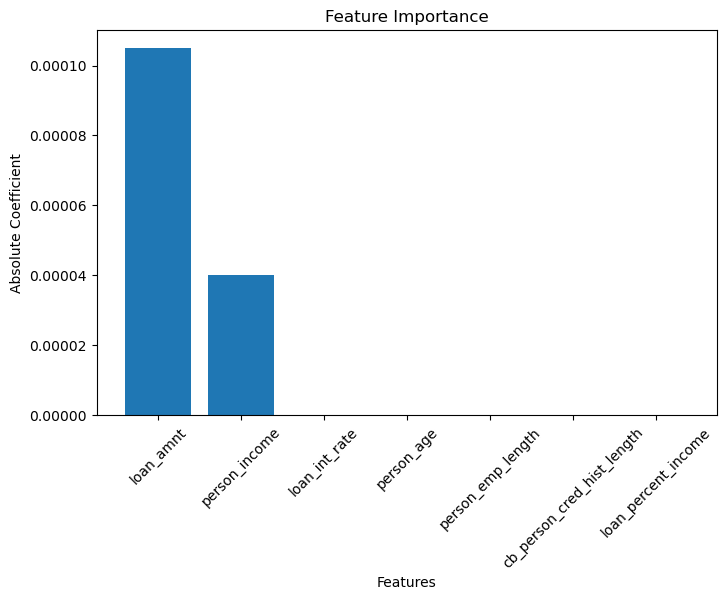

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df['feature'],
    importance_df['abs_coef']
)

plt.xticks(rotation=45)

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient')

plt.savefig('feature_importance_barplot.png', bbox_inches='tight')

plt.show()

## Feature Importance Insight

Loan amount has the highest coefficient magnitude in the model, followed by borrower income.

This suggests that these two variables contribute more to the prediction compared with the other selected numerical features.

The remaining variables have relatively small coefficient values and appear to have less influence on the model output.